<a href="https://colab.research.google.com/github/madekrisnaj/text2sql-capstone/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project 5: Text-to-SQL dengan Verifikasi Eksekusi

**Cara pakai:** jalankan sel secara berurutan dari atas ke bawah (Shift + Enter).
Baca teks di atas setiap sel sebelum menjalankannya. Jika sesi Colab terputus,
jalankan ulang **Bagian 0** lalu lanjutkan dari bagian terakhir.

## Bagian 0. Persiapan

**Sel 0.1** Hubungkan Google Drive

In [1]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Google Drive tidak tersedia (Jalur B / VM sendiri). Output disimpan di folder outputs/.", e)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Sel 0.2** Ambil kode dari GitHub dan install library

In [2]:
import os
GITHUB_USER = "madekrisnaj"
REPO_NAME = "text2sql-capstone"

if os.path.basename(os.getcwd()) != REPO_NAME:
    if not os.path.exists(REPO_NAME):
        !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git
    os.chdir(REPO_NAME)
!git pull
!pip install -q -r requirements.txt
print("Selesai. Folder kerja:", os.getcwd())

Already up to date.
Selesai. Folder kerja: /content/text2sql-capstone


**Sel 0.3** Muat token dari Colab Secrets

In [3]:
import os
try:
    from google.colab import userdata
    for key in ["HF_TOKEN", "HF_USERNAME", "NIM_API_KEY"]:
        os.environ[key] = userdata.get(key)
    print("Secrets berhasil dimuat.")
except Exception as e:
    print("Colab Secrets tidak tersedia. Pastikan sudah login lewat terminal VM (Jalur B).", e)

from huggingface_hub import login
if os.environ.get("HF_TOKEN"):
    login(token=os.environ["HF_TOKEN"])

Secrets berhasil dimuat.


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


**Sel 0.4** Cek GPU dan lokasi penyimpanan. Pastikan nama GPU muncul. Jika muncul error, ubah runtime ke GPU (Runtime > Change runtime type).

In [4]:
import sys, torch
sys.path.insert(0, ".")
from src import config as C

print("GPU        :", torch.cuda.get_device_name(0))
print("VRAM       :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
print("HF user    :", C.HF_USERNAME)
print("Folder hasil:", C.OUT)

GPU        : Tesla T4
VRAM       : 15.6 GB
HF user    : Kriskris28
Folder hasil: /content/drive/MyDrive/text2sql-capstone


In [5]:
import transformers, trl, peft, huggingface_hub
print("transformers   :", transformers.__version__)
print("trl            :", trl.__version__)
print("peft           :", peft.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("torch          :", torch.__version__)

transformers   : 4.46.3
trl            : 0.12.2
peft           : 0.13.2
huggingface_hub: 0.36.2
torch          : 2.11.0+cu128


## Bagian 1. Data: Load, Hapus Duplikat, Split per Skema

**Sel 1.1** Unduh dataset, hapus duplikat, lalu bagi menjadi train/val/test berdasarkan skema

In [7]:
import pandas as pd
from src.data import load_splits, check_leakage, query_type_stats

train_df, val_df, test_df = load_splits()
print("Cek kebocoran skema antar split (harus 0):", check_leakage(train_df, val_df, test_df))

train_df.to_parquet(C.DATA_DIR / "train.parquet")
val_df.to_parquet(C.DATA_DIR / "val.parquet")
test_df.to_parquet(C.DATA_DIR / "test.parquet")

Data awal: 78,577 | setelah hapus duplikat: 78,576
Cek kebocoran skema antar split (harus 0): {'train-val': 0, 'train-test': 0, 'val-test': 0}


**Sel 1.2** Statistik korpus untuk Section 2 laporan. Perhatikan kolom `join_%`: angkanya kecil, sehingga kemampuan JOIN diuji lewat studi kasus (Bagian 7).

In [8]:
stats = pd.DataFrame({"train": query_type_stats(train_df),
                      "val": query_type_stats(val_df),
                      "test": query_type_stats(test_df)})
stats.to_csv(C.RESULT_DIR / "statistik_korpus.csv")
stats

,train,val,test
jumlah_sampel,15000.00,3935.00,7874.00
jumlah_skema,14681.00,3648.00,7294.00
join_%,2.15,2.54,2.20
group_by_%,1.63,1.60,1.46
order_by_%,1.43,1.55,1.24
agregasi_%,29.27,29.07,29.22
rata2_kata_pertanyaan,11.50,11.60,11.60


## Bagian 2. Uji Evaluator

**Sel 2.1** Pastikan evaluator bekerja benar sebelum dipakai. Output yang diharapkan: baris 1 `ex=True`, baris 2 `ex=False`, baris 3 dan 4 `syntax_ok=False`.

In [9]:
from src.execution_evaluator import evaluate_pair

ctx = "CREATE TABLE head (age INTEGER, name VARCHAR)"
gold = "SELECT COUNT(*) FROM head WHERE age > 56"
print("1. Prediksi identik    :", evaluate_pair(ctx, gold, gold))
print("2. Prediksi salah      :", evaluate_pair(ctx, gold, "SELECT COUNT(*) FROM head WHERE age > 10"))
print("3. Prediksi rusak      :", evaluate_pair(ctx, gold, "SELEC nonsense"))
print("4. Prediksi berbahaya  :", evaluate_pair(ctx, gold, "DELETE FROM head"))

1. Prediksi identik    : {'gold_ok': True, 'gold_empty': False, 'syntax_ok': True, 'ex': True, 'em': True}
2. Prediksi salah      : {'gold_ok': True, 'gold_empty': False, 'syntax_ok': True, 'ex': False, 'em': False}
3. Prediksi rusak      : {'gold_ok': True, 'gold_empty': False, 'syntax_ok': False, 'ex': False, 'em': False}
4. Prediksi berbahaya  : {'gold_ok': True, 'gold_empty': False, 'syntax_ok': False, 'ex': False, 'em': False}


## Bagian 3. Baseline (sebelum fine-tuning)

**Sel 3.1** Ambil 1.000 sampel test tetap (seed 42). Sampel yang sama dipakai untuk semua model agar perbandingan adil.

In [10]:
from src.prompt import build_prompt

test_eval = test_df.sample(C.N_TEST_EVAL, random_state=C.SEED).reset_index(drop=True)
test_eval.to_parquet(C.DATA_DIR / "test_eval.parquet")
prompts = [build_prompt(r.context, r.question) for r in test_eval.itertuples()]
print(len(prompts), "prompt siap. Contoh:")
print(prompts[0][1]["content"])

1000 prompt siap. Contoh:
Schema:
CREATE TABLE table_name_3 (date VARCHAR, catalog VARCHAR, region VARCHAR)

Question: What's the date in the United Kingdom having a catalog of reveal50cd/lp?


**Sel 3.2** Generate SQL dengan model dasar Qwen2.5-1.5B (tanpa fine-tuning)

In [11]:
from src.infer import load_hf_model, generate_hf
from src.execution_evaluator import evaluate_frame, summarize

model, tok = load_hf_model(C.BASE_MODEL)
test_eval["pred_base"] = generate_hf(model, tok, prompts)
res_base = evaluate_frame(test_eval, "pred_base")
res_base.to_csv(C.RESULT_DIR / "hasil_base.csv", index=False)
summarize(res_base)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Generate:   0%|          | 0/63 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


{'n_dievaluasi': 980,
 'gold_rusak_%': np.float64(2.0),
 'gold_kosong_%': np.float64(12.04),
 'syntax_validity_%': np.float64(96.33),
 'exact_match_%': np.float64(59.08),
 'execution_accuracy_%': np.float64(66.12)}

**Sel 3.3** Clear memori GPU sebelum lanjut.

In [14]:
import gc
del model; gc.collect(); torch.cuda.empty_cache()
print("VRAM terpakai:", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")

VRAM terpakai: 0.01 GB


**Sel 3.4** Baseline model Mistral-Nemotron NIM via NVIDIA NIM pada 200 sampel pertama.

In [16]:
!git log --oneline -3
!grep -n "Cache:" src/infer.py

afa66cd (HEAD -> main, origin/main, origin/HEAD) Enhance clean_sql and update generate_nim function
5f04e49 Update NIM_MODEL and add NIM_EXTRA and NIM_MAX_TOKENS
a22907e Update README to simplify project overview


In [17]:
import os, time
from openai import OpenAI

client = OpenAI(base_url="https://integrate.api.nvidia.com/v1",
                api_key=os.environ["NIM_API_KEY"], timeout=60)
uji = {
    "A. Pesan sederhana": [{"role": "user", "content": "Say OK"}],
    "B. Prompt asli dataset": prompts[0],
}
for nama, pesan in uji.items():
    ok = 0
    for i in range(3):
        try:
            client.chat.completions.create(model=C.NIM_MODEL, messages=pesan,
                                           max_tokens=60, temperature=0)
            ok += 1
        except Exception as e:
            print(f"{nama} gagal: {str(e)[:60]}")
        time.sleep(3)
    print(f"{nama}: {ok}/3 berhasil\n")

A. Pesan sederhana gagal: Request timed out.


KeyboardInterrupt: 

In [15]:
from src.infer import generate_nim
from src.execution_evaluator import evaluate_frame, summarize

nim_df = test_eval.head(C.N_NIM_EVAL).copy()
nim_df["pred_nim"] = generate_nim(prompts[: C.N_NIM_EVAL], C.NIM_MODEL)

n_gagal = nim_df["pred_nim"].isna().sum()
if n_gagal:
    print(f"BELUM SELESAI: {n_gagal} sampel gagal karena server. Jalankan ulang sel ini.")
else:
    res_nim = evaluate_frame(nim_df, "pred_nim")
    res_nim.to_csv(C.RESULT_DIR / "hasil_nim.csv", index=False)
    display(summarize(res_nim))

NIM:   0%|          | 0/200 [00:00<?, ?it/s]

Percobaan 1 gagal: Error code: 500 - {'type': 'urn:inference-connection:problem-details:internal-server-error', 'title': 'Internal Server Error', 'status': 500, 'detail': 'Inference connection error while making inference request'}
Percobaan 2 gagal: Error code: 500 - {'type': 'urn:inference-connection:problem-details:internal-server-error', 'title': 'Internal Server Error', 'status': 500, 'detail': 'Inference connection error while making inference request'}
Percobaan 3 gagal: Error code: 500 - {'type': 'urn:inference-connection:problem-details:internal-server-error', 'title': 'Internal Server Error', 'status': 500, 'detail': 'Inference connection error while making inference request'}
Percobaan 1 gagal: Error code: 500 - {'type': 'urn:inference-connection:problem-details:internal-server-error', 'title': 'Internal Server Error', 'status': 500, 'detail': 'Inference connection error while making inference request'}


KeyboardInterrupt: 

In [13]:
from src.infer import generate_nim

nim_df = test_eval.head(C.N_NIM_EVAL).copy()
nim_df["pred_nim"] = generate_nim(prompts[: C.N_NIM_EVAL], C.NIM_MODEL)
res_nim = evaluate_frame(nim_df, "pred_nim")
res_nim.to_csv(C.RESULT_DIR / "hasil_nim.csv", index=False)
summarize(res_nim)

NIM:   0%|          | 0/200 [00:00<?, ?it/s]

Percobaan 1 gagal: Error code: 500
Percobaan 2 gagal: Error code: 500 - {'type': 'urn:inference-connection:problem-details:internal-server-error', 'title': 'Internal Server Error', 'status': 500, 'detail': 'Inference connection error while making inference request'}


KeyboardInterrupt: 

In [1]:
import os, time
from openai import OpenAI

client = OpenAI(base_url="https://integrate.api.nvidia.com/v1",
                api_key=os.environ["NIM_API_KEY"], timeout=60)
ok = 0
for i in range(5):
    try:
        client.chat.completions.create(model=C.NIM_MODEL, max_tokens=20, temperature=0,
                                       messages=[{"role": "user", "content": "Say OK"}])
        ok += 1
        print(f"{i+1}. berhasil")
    except Exception as e:
        print(f"{i+1}. gagal: {str(e)[:70]}")
    time.sleep(3)
print(f"\n{ok}/5 berhasil")

KeyError: 'NIM_API_KEY'

In [14]:
import os, time
from openai import OpenAI

client = OpenAI(base_url="https://integrate.api.nvidia.com/v1", api_key=os.environ["NIM_API_KEY"])
ids = sorted(m.id for m in client.models.list().data)

BESAR = ["70b", "405b", "235b", "120b", "maverick", "large"]
HINDARI = ["vision", "embed", "rerank", "guard", "safety", "reward", "r1", "think"]
kandidat = [m for m in ids if any(k in m.lower() for k in BESAR)
            and not any(k in m.lower() for k in HINDARI)]
print(f"{len(kandidat)} kandidat ditemukan\n")

uji = [{"role": "system", "content": "You are a SQLite expert. Return exactly one SQL query, no explanation."},
       {"role": "user", "content": "Schema:\nCREATE TABLE pelanggan (id INTEGER, kota TEXT)\n\n"
                                   "Question: How many customers live in Jakarta?"}]
for m in kandidat:
    try:
        t0 = time.time()
        r = client.chat.completions.create(model=m, messages=uji, temperature=0, max_tokens=80)
        out = (r.choices[0].message.content or "").strip().replace("\n", " ")
        print(f"OK    {m:50s} {time.time()-t0:4.1f}s | {out[:70]}")
    except Exception as e:
        print(f"GAGAL {m:50s} | {str(e)[:60]}")
    time.sleep(1)

12 kandidat ditemukan

GAGAL 01-ai/yi-large                                     | Error code: 404 - {'status': 404, 'title': 'Not Found', 'det
GAGAL ai21labs/jamba-1.5-large-instruct                  | Error code: 404 - {'status': 404, 'title': 'Not Found', 'det
GAGAL meta/codellama-70b                                 | Error code: 404 - {'status': 404, 'title': 'Not Found', 'det
GAGAL meta/llama2-70b                                    | Error code: 404 - {'status': 404, 'title': 'Not Found', 'det
GAGAL mistralai/mistral-large                            | Error code: 404 - {'status': 404, 'title': 'Not Found', 'det
GAGAL mistralai/mistral-large-2-instruct                 | Error code: 404 - {'status': 404, 'title': 'Not Found', 'det
GAGAL nvidia/llama-3.1-nemotron-70b-instruct             | Error code: 404 - {'status': 404, 'title': 'Not Found', 'det
GAGAL nvidia/llama3-chatqa-1.5-70b                       | Error code: 404 - {'status': 404, 'title': 'Not Found', 'det
OK    nvidia/nemo

In [15]:
def uji_model(m, extra=None, pesan=None):
    t0 = time.time()
    kw = {"extra_body": extra} if extra else {}
    r = client.chat.completions.create(model=m, messages=pesan or uji, temperature=0,
                                       max_tokens=400, **kw)
    msg = r.choices[0].message
    reasoning = getattr(msg, "reasoning_content", None) or (msg.model_extra or {}).get("reasoning_content")
    tokens = r.usage.completion_tokens if r.usage else None
    return round(time.time() - t0, 1), tokens, bool(reasoning), (msg.content or "").strip().replace("\n", " ")

CARI = ["llama-4", "deepseek", "qwen3", "kimi", "gpt-oss", "mistral-medium", "glm", "minimax", "nemotron"]
BUANG = ["embed", "rerank", "guard", "safety", "vision", "nano", "mini", "vl"]
kandidat2 = [m for m in ids if any(k in m.lower() for k in CARI)
             and not any(k in m.lower() for k in BUANG) and m not in kandidat]
print(f"{len(kandidat2)} kandidat tambahan\n")

for m in kandidat2:
    try:
        lat, tok, rsn, out = uji_model(m)
        print(f"OK    {m:50s} {lat:5.1f}s tok={tok} reasoning={rsn} | {out[:60]}")
    except Exception as e:
        print(f"GAGAL {m:50s} | {str(e)[:50]}")
    time.sleep(1)

15 kandidat tambahan

GAGAL deepseek-ai/deepseek-coder-6.7b-instruct           | Error code: 404 - {'status': 404, 'title': 'Not Fo
OK    mistralai/mistral-nemotron                           3.0s tok=15 reasoning=False | SELECT COUNT(*) FROM pelanggan WHERE kota = 'Jakarta';
GAGAL moonshotai/kimi-k2.6                               | Error code: 404 - {'status': 404, 'title': 'Not Fo
OK    moonshotai/kimi-k3                                 888.4s tok=41 reasoning=True | SELECT COUNT(*) FROM pelanggan WHERE kota = 'Jakarta';
GAGAL nvidia/llama-3.1-nemotron-51b-instruct             | Error code: 404 - {'status': 404, 'title': 'Not Fo
GAGAL nvidia/llama-3.1-nemotron-ultra-253b-v1            | Error code: 404 - {'status': 404, 'title': 'Not Fo
OK    nvidia/nemotron-3-ultra-550b-a55b                   36.1s tok=92 reasoning=True | SELECT COUNT(*) FROM pelanggan WHERE kota = 'Jakarta';
OK    nvidia/nemotron-3.5-lightning-30b-a3b               43.9s tok=16 reasoning=True | Here which......... 

In [16]:
from src.execution_evaluator import evaluate_pair
from src.infer import clean_sql

FINALIS = {
    "mistralai/mistral-nemotron": None,
    "nvidia/nemotron-3-super-120b-a12b": {"chat_template_kwargs": {"enable_thinking": False}},
}
sampel = test_eval.head(10)

for m, extra in FINALIS.items():
    latensi, benar, kosong, dinilai = [], 0, 0, 0
    kw = {"extra_body": extra} if extra else {}
    for (_, row), p in zip(sampel.iterrows(), prompts[:10]):
        t0 = time.time()
        try:
            r = client.chat.completions.create(model=m, messages=p, temperature=0, max_tokens=200, **kw)
            sql = clean_sql(r.choices[0].message.content)
        except Exception as e:
            print(f"{m} error: {str(e)[:60]}")
            sql = ""
        latensi.append(time.time() - t0)
        kosong += sql == ""
        hasil = evaluate_pair(row["context"], row["answer"], sql)
        if hasil["gold_ok"]:
            dinilai += 1
            benar += hasil["ex"]
        time.sleep(1)
    print(f"{m:40s} latensi={sum(latensi)/len(latensi):5.1f}s  EX={benar}/{dinilai}  kosong={kosong}")

mistralai/mistral-nemotron error: Error code: 500 - {'type': 'urn:inference-connection:problem
mistralai/mistral-nemotron error: Error code: 500 - {'type': 'urn:inference-connection:problem
mistralai/mistral-nemotron error: Error code: 504
mistralai/mistral-nemotron error: Error code: 500 - {'type': 'urn:inference-connection:problem
mistralai/mistral-nemotron error: Error code: 500 - {'type': 'urn:inference-connection:problem


KeyboardInterrupt: 

## Bagian 4. Fine-Tuning QLoRA

**Sel 4.1** CEK GPU T4
Jika sedang memakai GPU besar, lewati sel ini.

In [18]:
from src.train import train_qlora

torch.cuda.reset_peak_memory_stats()
_ = train_qlora(train_df, val_df, output_dir=C.CKPT_DIR / "uji_t4", max_steps=50)
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM puncak:", round(torch.cuda.max_memory_allocated() / 1e9, 2), "GB")

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

max_steps is given, it will override any value given in num_train_epochs


trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815


Step,Training Loss,Validation Loss


GPU: Tesla T4
VRAM puncak: 5.56 GB


**Sel 4.2** Pelatihan penuh (1 epoch, 15.000 sampel). Estimasi 40-70 menit di T4, lebih cepat di GPU besar.
Checkpoint disimpan otomatis setiap 200 langkah. Jika sesi putus, jalankan Bagian 0, Sel 1.1, lalu sel ini lagi. Pelatihan otomatis dilanjutkan dari checkpoint terakhir.

In [19]:
from src.train import train_qlora

trainer = train_qlora(train_df, val_df, output_dir=C.CKPT_DIR / "full")
trainer.save_model(str(C.CKPT_DIR / "adapter_final"))
print("Adapter tersimpan di", C.CKPT_DIR / "adapter_final")

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815


Step,Training Loss,Validation Loss
200,0.050300,0.056058
400,0.043100,0.046939
600,0.038900,0.042774
800,0.038300,0.040343


Adapter tersimpan di /content/drive/MyDrive/text2sql-capstone/checkpoints/adapter_final


**Sel 4.3** Simpan grafik training loss dan validation loss untuk Section 4 laporan.

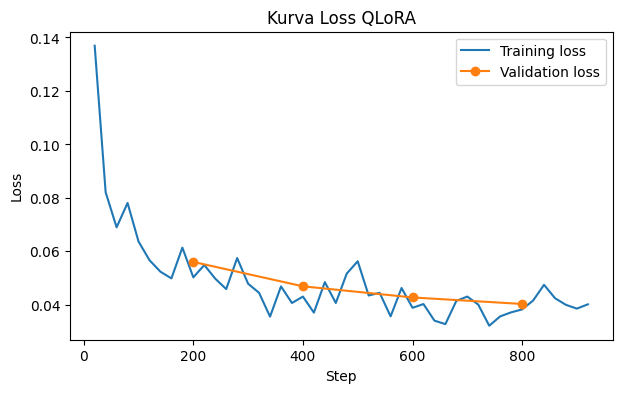

In [20]:
import matplotlib.pyplot as plt

log = pd.DataFrame(trainer.state.log_history)
tr_loss = log.dropna(subset=["loss"])
ev_loss = log.dropna(subset=["eval_loss"])
plt.figure(figsize=(7, 4))
plt.plot(tr_loss["step"], tr_loss["loss"], label="Training loss")
plt.plot(ev_loss["step"], ev_loss["eval_loss"], marker="o", label="Validation loss")
plt.xlabel("Step"); plt.ylabel("Loss"); plt.legend(); plt.title("Kurva Loss QLoRA")
plt.savefig(C.RESULT_DIR / "kurva_loss.png", dpi=150, bbox_inches="tight")
plt.show()

**Sel 4.4** Unggah adapter ke Hugging Face Hub.

In [21]:
trainer.model.push_to_hub(C.REPO_ADAPTER)
trainer.processing_class.push_to_hub(C.REPO_ADAPTER)
print("Adapter diunggah ke https://huggingface.co/" + C.REPO_ADAPTER)
del trainer; gc.collect(); torch.cuda.empty_cache()

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 25.9kB / 17.5MB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp2gbiwfcn/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Adapter diunggah ke https://huggingface.co/Kriskris28/qwen15-sql-lora


## Bagian 5. Evaluasi Model Fine-Tuned

**Sel 5.1** Generate SQL dengan model hasil fine-tuning pada 1.000 sampel test yang sama.

In [22]:
model, tok = load_hf_model(C.BASE_MODEL, adapter=C.REPO_ADAPTER)
test_eval["pred_ft"] = generate_hf(model, tok, prompts)
res_ft = evaluate_frame(test_eval, "pred_ft")
res_ft.to_csv(C.RESULT_DIR / "hasil_finetuned.csv", index=False)
summarize(res_ft)

adapter_config.json:   0%|          | 0.00/680 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

Generate:   0%|          | 0/63 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


{'n_dievaluasi': 980,
 'gold_rusak_%': np.float64(2.0),
 'gold_kosong_%': np.float64(11.33),
 'syntax_validity_%': np.float64(98.78),
 'exact_match_%': np.float64(73.88),
 'execution_accuracy_%': np.float64(84.69)}

## Bagian 6. Tabel Perbandingan, Uji Signifikansi, Analisis Galat

**Sel 6.0 (opsional)** Jalankan hanya jika sesi sempat putus setelah Bagian 5. Sel ini memuat ulang hasil evaluasi dari file, jadi Anda tidak perlu generate ulang.

In [8]:
from src.execution_evaluator import summarize
from src.prompt import build_prompt
import gc
res_base = pd.read_csv(C.RESULT_DIR / "hasil_base.csv")
res_ft = pd.read_csv(C.RESULT_DIR / "hasil_finetuned.csv")
test_eval = pd.read_parquet(C.DATA_DIR / "test_eval.parquet")
prompts = [build_prompt(r.context, r.question) for r in test_eval.itertuples()]
print("Hasil dimuat ulang.")

Hasil dimuat ulang.


**Sel 6.1** Tabel utama untuk Section 4 laporan.

In [9]:
from src.stats_utils import mcnemar_test, bootstrap_ci

ids_nim = set(range(C.N_NIM_EVAL))
tabel = pd.DataFrame({
    "Base Qwen 1.5B (n=1000)": summarize(res_base),
    "Fine-tuned Qwen 1.5B (n=1000)": summarize(res_ft),
    "Base Qwen 1.5B (n=200)": summarize(res_base.head(C.N_NIM_EVAL)),
    "Fine-tuned Qwen 1.5B (n=200)": summarize(res_ft.head(C.N_NIM_EVAL)),
}).T
tabel.to_csv(C.RESULT_DIR / "tabel_perbandingan.csv")
tabel

,n_dievaluasi,gold_rusak_%,gold_kosong_%,syntax_validity_%,exact_match_%,execution_accuracy_%
Base Qwen 1.5B (n=1000),980.0,2.0,12.04,96.33,59.08,66.12
Fine-tuned Qwen 1.5B (n=1000),980.0,2.0,11.33,98.78,73.88,84.69
Base Qwen 1.5B (n=200),196.0,2.0,13.78,95.92,56.12,63.27
Fine-tuned Qwen 1.5B (n=200),196.0,2.0,13.27,98.47,73.47,87.24


**Sel 6.2** Uji McNemar (base vs fine-tuned) dan confidence interval 95%. Kenaikan signifikan jika p-value < 0,05.

In [10]:
mask = res_base["gold_ok"] & res_ft["gold_ok"]
uji = mcnemar_test(res_base.loc[mask, "ex"], res_ft.loc[mask, "ex"])
uji["CI95_EX_base_%"] = bootstrap_ci(res_base.loc[mask, "ex"])
uji["CI95_EX_finetuned_%"] = bootstrap_ci(res_ft.loc[mask, "ex"])
pd.Series(uji).to_csv(C.RESULT_DIR / "uji_signifikansi.csv")
pd.Series(uji)

,0
base_benar_ft_salah,33
base_salah_ft_benar,215
p_value,0.0
CI95_EX_base_%,"(63.27, 69.08)"
CI95_EX_finetuned_%,"(82.45, 86.94)"


**Sel 6.3** Skor per jenis query (JOIN vs non-JOIN) dan kategori galat otomatis.

In [11]:
from src.data import has_join
from src.stats_utils import auto_tag

res_ft["tipe"] = res_ft["answer"].map(lambda s: "join" if has_join(s) else "non_join")
per_tipe = res_ft[res_ft["gold_ok"]].groupby("tipe")[["syntax_ok", "em", "ex"]].mean().mul(100).round(2)
per_tipe["n"] = res_ft[res_ft["gold_ok"]].groupby("tipe").size()
display(per_tipe)

salah = res_ft[res_ft["gold_ok"] & ~res_ft["ex"]].copy()
salah["kategori_otomatis"] = [auto_tag(g, p, s) for g, p, s in zip(salah["answer"], salah["pred"], salah["syntax_ok"])]
display(salah["kategori_otomatis"].value_counts())

sampel = salah.sample(min(50, len(salah)), random_state=C.SEED)
sampel["kategori_manual"] = ""
sampel[["question", "context", "answer", "pred", "kategori_otomatis", "kategori_manual"]].to_csv(
    C.RESULT_DIR / "sampel_galat_untuk_dicek.csv", index=False)
print("File sampel_galat_untuk_dicek.csv siap diperiksa manual.")

,syntax_ok,em,ex,n
tipe,,,,
join,68.42,5.26,31.58,19
non_join,99.38,75.23,85.74,961


,count
kategori_otomatis,
beda_agregasi,57
beda_kolom,48
lainnya,32
gagal_eksekusi,12
beda_nilai_literal,1


File sampel_galat_untuk_dicek.csv siap diperiksa manual.


## Bagian 7. Studi Kasus E-Commerce Indonesia (uji JOIN dan bahasa Indonesia)

**Sel 7.1** Uji model fine-tuned pada 20 pertanyaan berbahasa Indonesia terhadap database e-commerce.

In [34]:
import json, sqlite3, gc
from src.infer import load_hf_model, generate_hf
from src.execution_evaluator import evaluate_on_db

cs = pd.read_json(C.CASE_STUDY_FILE, lines=True)
con = sqlite3.connect(C.ECOMMERCE_DB)
schema_cs = "\n".join(r[0] for r in con.execute("SELECT sql FROM sqlite_master WHERE type='table'"))
con.close()
cs_prompts = [build_prompt(schema_cs, q) for q in cs["question"]]

def eval_case_study(preds):
    rows = [evaluate_on_db(C.ECOMMERCE_DB, g, p) for g, p in zip(cs["gold"], preds)]
    return pd.DataFrame(rows)

if "model" in globals():
    del model; gc.collect(); torch.cuda.empty_cache()
model, tok = load_hf_model(C.BASE_MODEL, adapter=C.REPO_ADAPTER)
cs["pred_ft"] = generate_hf(model, tok, cs_prompts)
cs_ft = pd.concat([cs, eval_case_study(cs["pred_ft"])], axis=1)
cs_ft[["question", "pred_ft", "ex"]]

Generate:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


,question,pred_ft,ex
0,Berapa jumlah pelanggan yang tinggal di Jakarta?,"SELECT COUNT(*) FROM pelanggan WHERE kota = ""J...",True
1,Tampilkan nama dan harga semua barang kategori...,"SELECT b.nama_barang, b.harga FROM barang AS b...",False
2,Berapa harga barang termahal?,"SELECT MAX(harga), nama_barang FROM barang WHE...",False
3,Berapa rata-rata harga barang kategori Fashion?,SELECT AVG(barang.harga) FROM transaksi JOIN i...,False
4,Berapa total pendapatan dari seluruh transaksi?,SELECT SUM(total) FROM transaksi,True
5,Berapa jumlah transaksi pada bulan Maret 2025?,SELECT COUNT(*) FROM transaksi WHERE tanggal L...,False
6,Tampilkan jumlah pelanggan di setiap kota.,"SELECT COUNT(*), kota FROM pelanggan GROUP BY ...",False
7,Kategori barang apa saja yang tersedia?,SELECT DISTINCT kategori FROM barang,True
8,Tampilkan 3 barang termurah beserta harganya.,"SELECT t2.nama_barang, t1.harga FROM transaksi...",False
9,Berapa banyak barang yang harganya di atas 1 j...,SELECT COUNT(*) FROM barang WHERE harga > 1000000,True


**Sel 7.2** Uji model dasar pada studi kasus yang sama, lalu ringkas hasilnya.

In [28]:
del model; gc.collect(); torch.cuda.empty_cache()
model, tok = load_hf_model(C.BASE_MODEL)
cs["pred_base"] = generate_hf(model, tok, cs_prompts)
cs_base = pd.concat([cs, eval_case_study(cs["pred_base"])], axis=1)

ringkas_cs = pd.DataFrame({
    "base": cs_base.groupby("tipe")["ex"].mean().mul(100).round(1),
    "fine_tuned": cs_ft.groupby("tipe")["ex"].mean().mul(100).round(1),
})
ringkas_cs.loc["total"] = [cs_base["ex"].mean() * 100, cs_ft["ex"].mean() * 100]
cs_ft.to_csv(C.RESULT_DIR / "studi_kasus_finetuned.csv", index=False)
cs_base.to_csv(C.RESULT_DIR / "studi_kasus_base.csv", index=False)
ringkas_cs.to_csv(C.RESULT_DIR / "studi_kasus_ringkas.csv")
del model; gc.collect(); torch.cuda.empty_cache()
ringkas_cs

Generate:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


,base,fine_tuned
tipe,,
join,88.9,55.6
non_join,72.7,36.4
total,80.0,45.0


## Bagian 8. Merge, Konversi GGUF, Unggah ke Hugging Face

**Sel 8.1** Gabungkan adapter ke bobot model fp16. Estimasi 2-3 menit.

In [35]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

base = AutoModelForCausalLM.from_pretrained(C.BASE_MODEL, torch_dtype=torch.float16)
merged = PeftModel.from_pretrained(base, C.REPO_ADAPTER).merge_and_unload()
merged.save_pretrained("merged")
AutoTokenizer.from_pretrained(C.BASE_MODEL).save_pretrained("merged")
del base, merged; gc.collect()
print("Model gabungan tersimpan di folder merged/")

Model gabungan tersimpan di folder merged/


**Sel 8.2** Konversi ke GGUF dan kuantisasi Q4_K_M. Estimasi 5-10 menit (kompilasi llama.cpp).

In [36]:
!git clone --depth 1 https://github.com/ggml-org/llama.cpp
!pip install -q ./llama.cpp/gguf-py sentencepiece protobuf
!python llama.cpp/convert_hf_to_gguf.py merged --outfile model-f16.gguf --outtype f16
!cmake -S llama.cpp -B build -DLLAMA_CURL=OFF > /dev/null && cmake --build build --target llama-quantize -j 4 > /dev/null
!./build/bin/llama-quantize model-f16.gguf {C.GGUF_FILE} Q4_K_M
!ls -lh *.gguf

Cloning into 'llama.cpp'...
remote: Enumerating objects: 3969, done.
remote: Counting objects: 100% (3969/3969), done.
remote: Compressing objects: 100% (3293/3293), done.
remote: Total 3969 (delta 705), reused 2625 (delta 594), pack-reused 0 (from 0)
Receiving objects: 100% (3969/3969), 36.05 MiB | 17.28 MiB/s, done.
Resolving deltas: 100% (705/705), done.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 94.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.3 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.1

**Sel 8.3** Unggah file GGUF dan Modelfile Ollama ke Hugging Face Hub (repo publik).

In [37]:
from huggingface_hub import HfApi

api = HfApi()
api.create_repo(C.REPO_GGUF, exist_ok=True, private=False)
api.upload_file(path_or_fileobj=C.GGUF_FILE, path_in_repo=C.GGUF_FILE, repo_id=C.REPO_GGUF)
api.upload_file(path_or_fileobj="ollama/Modelfile", path_in_repo="Modelfile", repo_id=C.REPO_GGUF)
print("GGUF diunggah ke https://huggingface.co/" + C.REPO_GGUF)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  q15-sql-q4_k_m.gguf         :   0%|          | 1.10MB /  986MB            

GGUF diunggah ke https://huggingface.co/Kriskris28/qwen15-sql-gguf


## Bagian 9. Evaluasi Ulang Model GGUF (dampak kuantisasi)

**Sel 9.1** Install llama-cpp-python lalu uji GGUF pada 150 sampel test. Berjalan di CPU, estimasi 15-30 menit.

In [39]:
!pip uninstall -y -q llama-cpp-python
!CMAKE_BUILD_PARALLEL_LEVEL=8 pip install -q --no-cache-dir --no-binary llama-cpp-python llama-cpp-python
!pip show llama-cpp-python | grep Version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 MB 113.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
Version: 0.3.35


In [ ]:
from src.infer import generate_gguf
from src.execution_evaluator import evaluate_frame, summarize

gguf_df = test_eval.head(C.N_GGUF_EVAL).copy()
gguf_df["pred_gguf"] = generate_gguf(prompts[: C.N_GGUF_EVAL], C.REPO_GGUF, C.GGUF_FILE)
res_gguf = evaluate_frame(gguf_df, "pred_gguf")
res_gguf.to_csv(C.RESULT_DIR / "hasil_gguf.csv", index=False)

pd.DataFrame({
    "fp16 + adapter (n=150)": summarize(res_ft.head(C.N_GGUF_EVAL)),
    "GGUF Q4_K_M (n=150)": summarize(res_gguf),
}).T

## Bagian 10. Selesai

**Sel 10.1** Daftar semua file hasil. File-file ini dipakai untuk laporan.

In [15]:
for f in sorted(C.RESULT_DIR.iterdir()):
    print(f.name)

hasil_base.csv
hasil_finetuned.csv
kurva_loss.png
sampel_galat_untuk_dicek.csv
statistik_korpus.csv
studi_kasus_base.csv
studi_kasus_finetuned.csv
studi_kasus_ringkas.csv
tabel_perbandingan.csv
uji_signifikansi.csv
